In [14]:
import amocatlas as amoc
from amocatlas import read
import xarray as xr
import os
import matplotlib.pyplot as plt
from scipy.signal import welch

### Target
- selected dataset: The Calafat 2025 Reconstruted AMOC dataset
- target variable: Meridional Heat Transport(MHT), unit: Petawatts(PW)
- location: 35°N(from 30.5°N to 40.0°N)
- time span: 2004-2-14 to 2020-8-14

### Why?
- 1) This dataset has been fully processed, there's no missing data, which ensures the code runs soomthly without complex operation.
- 2) MHT measures the actual heat transport, not the transport convergence(HTC did). It directly reflects how the ocean transfersthermal evergy, which has a strong connect with climate change and seasonal patterns.
- 3) 35°N sits under the mid-latitude Westerlies wind belt. The ocean surface transport is strongly driven by powerful seasonal winds here, which dominates the large-sclae heat transport across locally. By visualizing the large-scale heat transport, we can see how the wind variability changes the mode of heat transport.

### Operation for posterior samples
- The biggest difference between Calafat 2025 from the other datasets is that the Calafat is a reconstructed dataset. Scientists used Bayesian model to simulate the value, but they were not sure about which one is the most realistic value. So they did 4,000 simulations. Therefore, for every point (temporal and spatial dimensions), there're 4,000 values, and we call them posterior samples.
- Use unweighted arithmetic mean to get the sample mean value, and take it as the best-estimate value, after that we can create a one-scalar time series.

In [3]:
ds = read.calafat2025()
series_35n = ds['MHT'].isel(lat=4).mean(dim='posterior_samples')

# found the first point is NaN, remove it

series_35n = series_35n.dropna(dim='TIME')

Loading 1 Calafat et al. 2025 dataset(s):
  0. Bayesian_estimates_Atlantic_MHT.zip: No description available



In [ ]:
series_35n.mean()
# temporal Mean: 1.0699 PW 

# 1 Petawatt = 10^15 W

In [ ]:
series_35n.std()
# Standard Deviation: 0.1424 PW

# Part A

In [10]:
times = series_35n['TIME'].values
mht_values = series_35n.values

mean_val = 1.0699
std_val = 0.1424

<>:14: SyntaxWarning: invalid escape sequence '\m'
<>:19: SyntaxWarning: invalid escape sequence '\s'
<>:14: SyntaxWarning: invalid escape sequence '\m'
<>:19: SyntaxWarning: invalid escape sequence '\s'
C:\Users\Administrator\AppData\Local\Temp\ipykernel_33468\3895636490.py:14: SyntaxWarning: invalid escape sequence '\m'
  label=f'Temporal Mean ($\mu$ = {mean_val:.4f} PW)')
C:\Users\Administrator\AppData\Local\Temp\ipykernel_33468\3895636490.py:19: SyntaxWarning: invalid escape sequence '\s'
  color='#bdc3c7', alpha=0.15, label=f'Standard Deviation ($\sigma$ = $\pm${std_val:.4f} PW)')


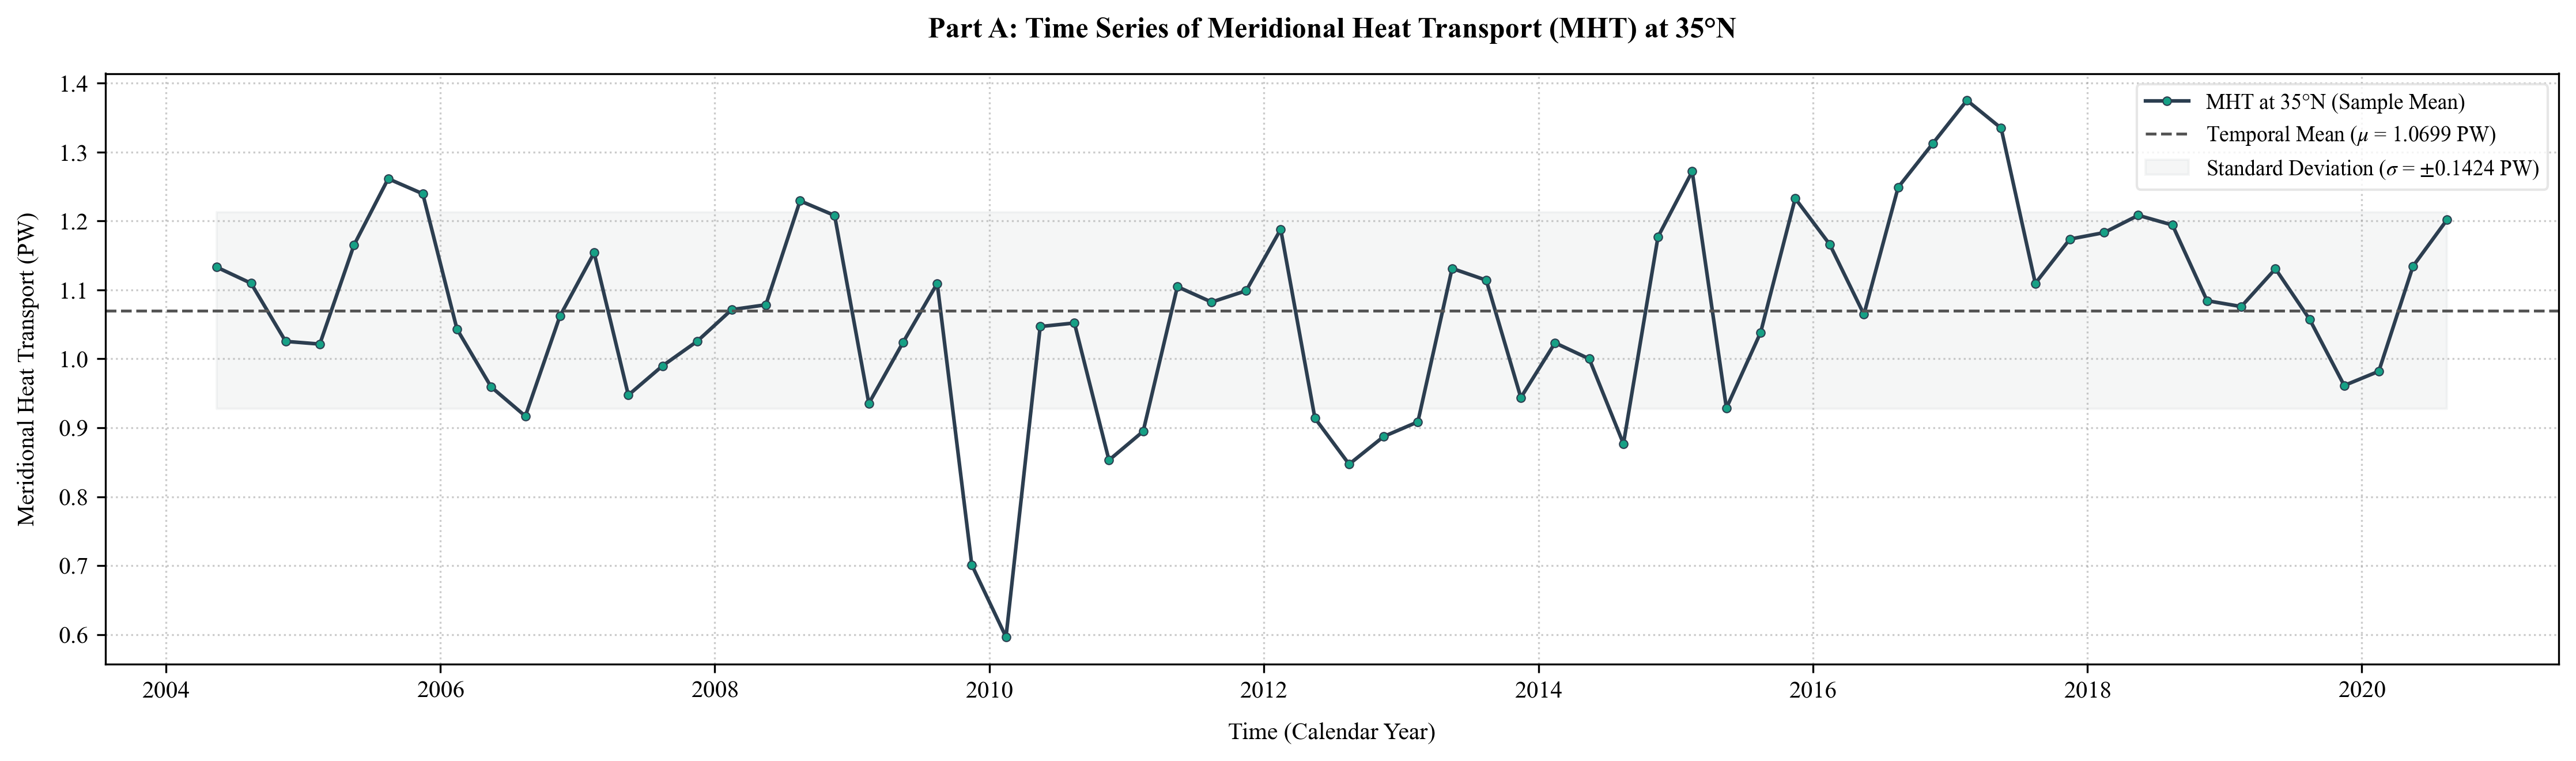

In [12]:
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = ['Times New Roman'] + plt.rcParams['font.serif']
plt.rcParams['mathtext.fontset'] = 'stix'

plt.figure(figsize=(15, 4.5), dpi=300)

# fluctuation
plt.plot(times, mht_values, color='#2c3e50', linestyle='-', linewidth=1.5,
         marker='o', markersize=3.5, markerfacecolor='#16a085', markeredgecolor='#2c3e50', markeredgewidth=0.5,
         label='MHT at 35°N (Sample Mean)')

# mean
plt.axhline(y=mean_val, color='#555555', linestyle='--', linewidth=1.2, 
            label=f'Temporal Mean ($\mu$ = {mean_val:.4f} PW)')


# standard deviation
plt.fill_between(times, mean_val - std_val, mean_val + std_val, 
                 color='#bdc3c7', alpha=0.15, label=f'Standard Deviation ($\sigma$ = $\pm${std_val:.4f} PW)')

# decoration
plt.title('Part A: Time Series of Meridional Heat Transport (MHT) at 35°N', fontsize=12, fontweight='bold', pad=15)
plt.xlabel('Time (Calendar Year)', fontsize=10, labelpad=8)
plt.ylabel('Meridional Heat Transport (PW)', fontsize=10, labelpad=8)
plt.grid(True, linestyle=':', alpha=0.5, color='#999999')

# legend
plt.legend(loc='best', frameon=True, facecolor='white', edgecolor='#e0e0e0', fontsize=9)

plt.tight_layout()
plt.show()

# Part B: Spectrum Figure

Using Welch Method

X-axis(frequency) : year

Y-axis(Power Spectral Density): It represents the energy intensity (variance/energy) of the data at a specific frequency or period.

In [15]:
mht_values = series_35n.values

frequencies, psd = welch(mht_values, fs=12.0, nperseg=36, detrend='linear')

<>:20: SyntaxWarning: invalid escape sequence '\c'
<>:20: SyntaxWarning: invalid escape sequence '\c'
C:\Users\Administrator\AppData\Local\Temp\ipykernel_33468\2683437490.py:20: SyntaxWarning: invalid escape sequence '\c'
  plt.ylabel('Power Spectral Density ($PW^2 / cyc\cdot yr^{-1}$)', fontsize=15, labelpad=10)


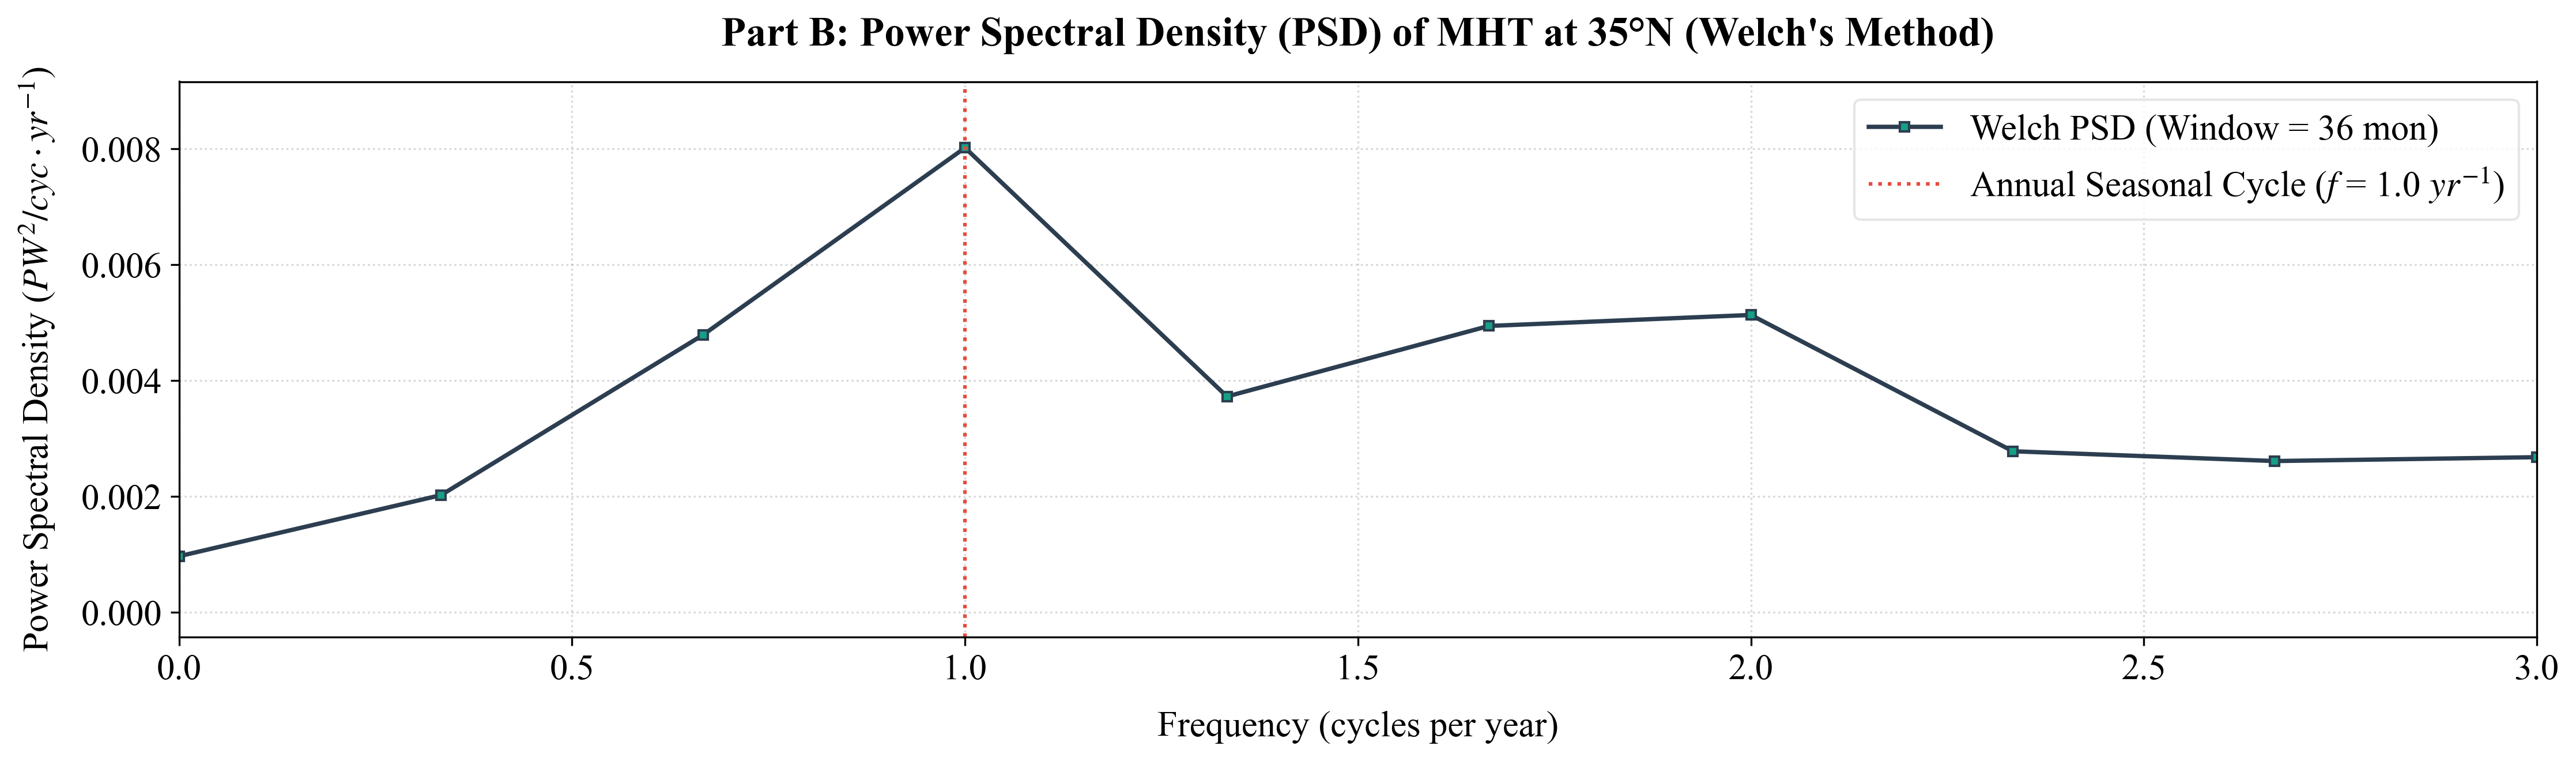

In [21]:
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = ['Times New Roman'] + plt.rcParams['font.serif']
plt.rcParams['mathtext.fontset'] = 'stix'

plt.figure(figsize=(15, 4.5), dpi=300)

# spectrum
plt.plot(frequencies, psd, color='#2c3e50', linestyle='-', linewidth=1.8,
         marker='s', markersize=4, markerfacecolor='#16a085', markeredgecolor='#2c3e50',
         label="Welch PSD (Window = 36 mon)")

# tag wind effect
plt.axvline(x=1.0, color='#e74c3c', linestyle=':', linewidth=1.5, 
            label='Annual Seasonal Cycle ($f$ = 1.0 $yr^{-1}$)')


# decoration
plt.title("Part B: Power Spectral Density (PSD) of MHT at 35°N (Welch's Method)", fontsize=17, fontweight='bold', pad=15)
plt.xlabel('Frequency (cycles per year)', fontsize=15, labelpad=10)
plt.ylabel('Power Spectral Density ($PW^2 / cyc\cdot yr^{-1}$)', fontsize=15, labelpad=10)
plt.xticks(fontsize=15)
plt.yticks(fontsize=15)
plt.grid(True, linestyle=':', alpha=0.4, color='#999999')

plt.xlim(0, 3.0) # we focus on the low frequency event and annual change, so choose (0, 3.0) as the frequancy boundaries.

# legend
plt.legend(loc='best', frameon=True, facecolor='white', edgecolor='#e0e0e0', fontsize=15)

plt.tight_layout()
plt.show()


X-axis: frequency, and the period = 1 year

Y-axis: represents the power spectral denstity(PSD), A higher spectral peak means the cyclical component has more thermal energy, and plays a more dominant role.

In this figure, I found f = 1.0 (also the 1 year period) dominates, which reflects that the Meridional Heat Transport is siginificantly effected by the seasonal forcing from Westerlies.

What I have is monthly data, and there're only 66 points, so I don't need to smooth the noise. If I add a filter, there will be no significant signal.